# 🚢 Titanic Exploratory Data Analysis

## Executive Summary

This project explores survival patterns in the Titanic dataset.  
The analysis reveals that gender and passenger class were the most influential factors affecting survival, while fare showed a moderate positive correlation with survival probability.

## 🎯 Objective

The goal of this analysis is to explore survival patterns and identify the key factors (such as gender, passenger class, and age) that significantly influenced passenger survival.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


## 📊 Dataset Overview

We begin by exploring the structure of the dataset, including the number of rows, columns, and data types.

In [2]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 📊 Overall Survival Distribution

We begin by examining the overall survival distribution to understand the proportion of passengers who survived versus those who did not.

In [6]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [7]:
df["Survived"].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


### 🔎 Insight

Approximately 38% of passengers survived, while 62% did not. This indicates that the majority of passengers did not survive the disaster.

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 🧹 Data Cleaning

We handle missing values and convert appropriate columns into categorical data types to improve analysis accuracy.

In [9]:
df.drop("Cabin", axis=1, inplace=True)

In [10]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipython-input-162/122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [11]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipython-input-162/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(3), float64(2), int64(4), object(2)
memory usage: 58.8+ KB


### Cleaning Summary

- Dropped Cabin due to excessive missing values.
- Filled missing Age values using the median.
- Filled missing Embarked values using the mode.
- Converted categorical variables to appropriate data types.

## 👩‍👩‍👦 Survival by Gender

We analyze survival rates based on gender to determine whether gender influenced survival probability.

In [15]:
df.groupby("Sex")["Survived"].mean()

/tmp/ipython-input-162/3474313431.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Sex")["Survived"].mean()


,Survived
Sex,
female,0.742038
male,0.188908


### 🔎 Insight

Female passengers had a significantly higher survival rate compared to males. This suggests that gender was the strongest factor influencing survival.

## 🎟 Survival by Passenger Class

We analyze survival rates across passenger classes to evaluate the impact of socioeconomic status.

In [16]:
df.groupby("Pclass")["Survived"].mean()

/tmp/ipython-input-162/2821951767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Pclass")["Survived"].mean()


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


### 🔎 Insight

First-class passengers had the highest survival rate, while third-class passengers had the lowest. This highlights the impact of social class on survival chances.

## 👑 Survival by Gender and Class

This section explores the combined impact of gender and passenger class on survival probability.

In [17]:
df.groupby(["Pclass", "Sex"])["Survived"].mean()

/tmp/ipython-input-162/2055767397.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Pclass", "Sex"])["Survived"].mean()


Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

### 🔎 Insight

First-class females had the highest survival rate, while third-class males had the lowest. This confirms that both gender and class played a crucial role in survival outcomes.

## 👶 Survival by Age Group

Passengers are grouped into age categories to determine whether age influenced survival.

In [18]:
df["AgeGroup"] = pd.cut(df["Age"],
                        bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

In [19]:
df.groupby("AgeGroup")["Survived"].mean()

/tmp/ipython-input-162/2602041343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Young Adult,0.353271
Adult,0.400000
Senior,0.227273


### 🔎 Insight

Children had higher survival rates compared to most adult groups, while senior passengers had the lowest survival rates. However, age was less influential than gender.

## 🚢 Survival by Port of Embarkation

We examine whether the port of embarkation had any influence on survival rates.

In [20]:
df.groupby("Embarked")["Survived"].mean()

/tmp/ipython-input-162/1588154530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Embarked")["Survived"].mean()


,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


### 🔎 Insight

Passengers embarking from Cherbourg had higher survival rates, likely due to a higher proportion of first-class passengers boarding from that port.

## 🔗 Correlation Analysis

We analyze correlations between numerical features to identify relationships with survival.

In [21]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.corr()

,PassengerId,Survived,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.064910,-0.035322,0.081629,0.257307
Age,0.034212,-0.064910,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,0.096688,0.159651,0.216225,1.000000


### 🔎 Key Observations

Fare showed the strongest positive correlation with survival among numerical features. Age and family-related variables showed weak correlations.

## 👩‍👩‍👦 Survival Rate by Gender

This visualization shows the survival probability based on passenger gender.

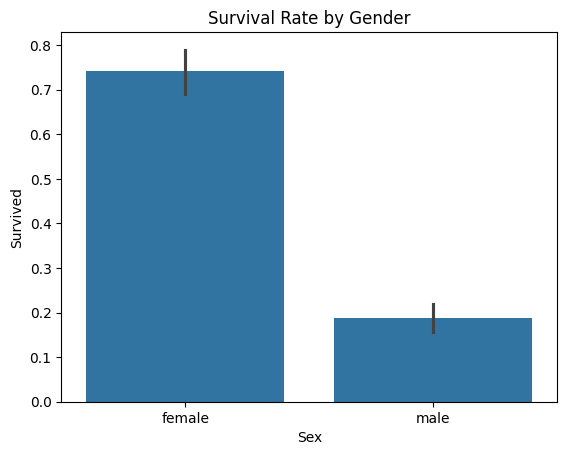

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

### Interpretation

The bar plot clearly shows that female passengers had a significantly higher survival rate compared to male passengers. This confirms that gender was the strongest determinant of survival.

## 🎟 Survival Rate by Passenger Class

This visualization examines survival probability across passenger classes.

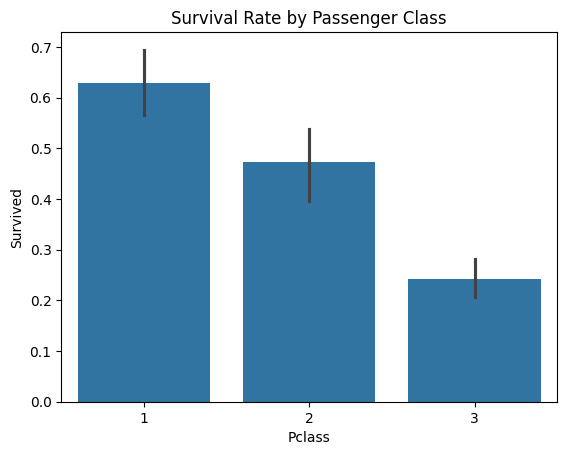

In [23]:
plt.figure()
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

### Interpretation

Survival rates decrease from first to third class. First-class passengers had the highest survival rate, highlighting the impact of socioeconomic status on survival outcomes.

## 🔗 Correlation Matrix

This heatmap visualizes relationships between numerical features and survival.

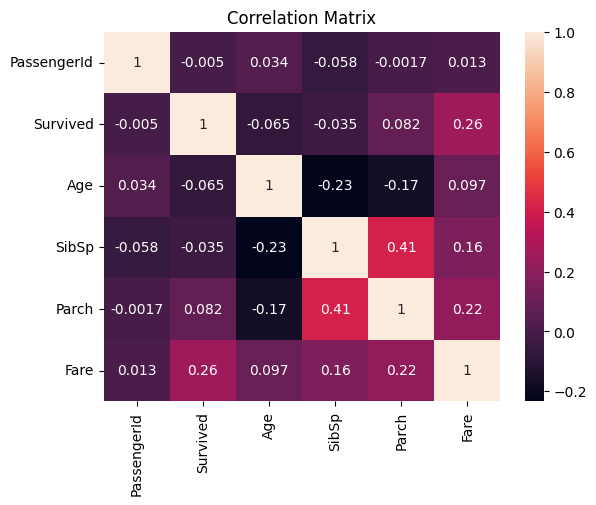

In [24]:
plt.figure()
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

### Interpretation

Fare shows the strongest positive correlation with survival among numerical features. Age and family-related features exhibit weak correlations, suggesting that categorical variables such as gender and class had a stronger influence on survival.

## 👑 Survival by Passenger Class and Gender

This visualization explores the combined impact of passenger class and gender on survival probability.

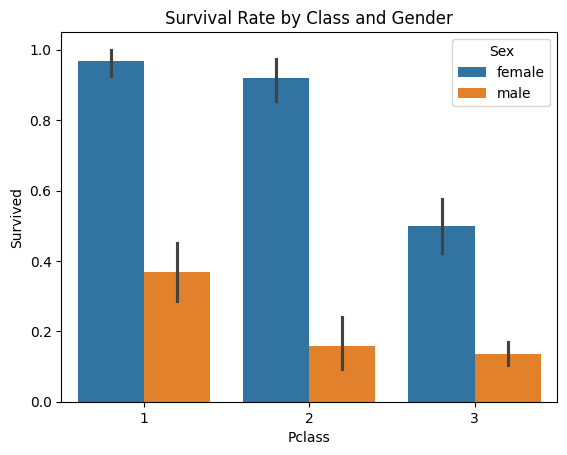

In [25]:
plt.figure()
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df)
plt.title("Survival Rate by Class and Gender")
plt.show()

### Interpretation

First-class females had the highest survival rate, while third-class males had the lowest. This confirms that both gender and socioeconomic status significantly influenced survival outcomes.

## 📈 Age Distribution by Survival

This histogram compares the age distribution of survivors and non-survivors.

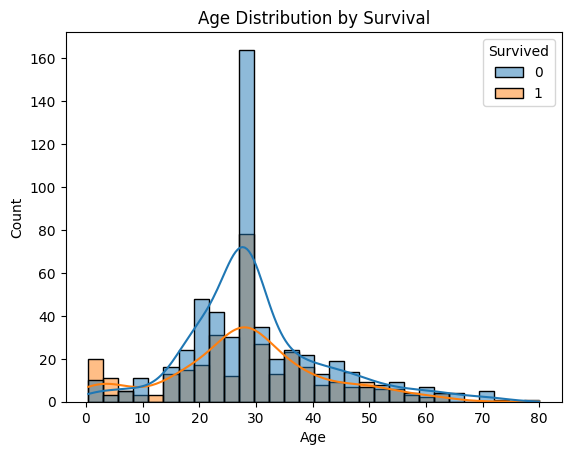

In [26]:
plt.figure()
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

### Interpretation

Children appear more frequently among survivors, while older passengers are less represented among survivors. However, age was less influential compared to gender and passenger class.

# 🏁 Final Conclusion

The analysis demonstrates that survival on the Titanic was not random.  
Gender was the most influential survival factor, followed by passenger class and fare.  

Women and first-class passengers had significantly higher survival rates.

This project highlights the importance of exploratory data analysis in uncovering meaningful insights within real-world datasets.